# Part 3 — Churn Prediction Model

**Target:** `churn_next_60d` (1 = no purchase in 60 days after snapshot)

All features reflect state **on or before 2025-09-30**. Target window: **2025-10-01 to 2025-11-29**. No future data used in `X`.


In [1]:
import json
from pathlib import Path

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = Path('..') / 'rfm_modeling_snapshot.csv'
assert DATA_PATH.exists(), f'Copy or place data at {DATA_PATH}'


c:\Users\Keshav Verma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Phase 1 — Load data & leakage guardrails

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Snapshot unique:', df['snapshot_date'].unique())
print(df.dtypes)
print('\nChurn distribution:')
print(df['churn_next_60d'].value_counts(normalize=True))
print('\nSplit counts:')
print(df['split'].value_counts())

FEATURE_COLS = [c for c in df.columns if c not in ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']]
print('\nFeature columns ({})'.format(len(FEATURE_COLS)))
print(FEATURE_COLS)
assert (df['snapshot_date'] == '2025-09-30').all()


Shape: (2400, 29)
Snapshot unique: <ArrowStringArray>
['2025-09-30']
Length: 1, dtype: str
customer_id                     str
snapshot_date                   str
city_tier                       str
age_group                       str
acquisition_channel             str
loyalty_tier                    str
preferred_category              str
marketing_consent               str
recency_days                  int64
frequency_180d                int64
monetary_180d               float64
return_rate_180d            float64
avg_discount_pct_180d       float64
avg_rating_180d             float64
category_diversity_180d       int64
ticket_count_90d              int64
negative_ticket_rate_90d    float64
avg_resolution_hours_90d    float64
days_since_signup             int64
sessions_30d                  int64
product_views_30d             int64
cart_adds_30d                 int64
wishlist_adds_30d             int64
abandoned_carts_30d           int64
email_opens_30d               int64
campaign_

**Leakage check:** Features are engineered from orders/support/web activity on or before the snapshot.
`churn_next_60d` and `split` are excluded from training features.


## Phase 2 — Feature prep & train/val/test split

In [3]:
DROP_COLS = ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']
CAT_COLS = ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

y = df['churn_next_60d']
X = df.drop(columns=DROP_COLS)
for col in CAT_COLS:
    X[col] = X[col].fillna('Unknown').astype(str)

mask_train = df['split'] == 'train'
mask_val = df['split'] == 'validation'
mask_test = df['split'] == 'test'

assert 'churn_next_60d' not in X.columns and 'split' not in X.columns

numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUM_COLS),
    ('cat', categorical_pipe, CAT_COLS),
])

X_train = preprocessor.fit_transform(X[mask_train])
X_val = preprocessor.transform(X[mask_val])
X_test = preprocessor.transform(X[mask_test])

feature_names = list(NUM_COLS)
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
feature_names += ohe.get_feature_names_out(CAT_COLS).tolist()

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df = pd.DataFrame(X_val, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

y_train, y_val, y_test = y[mask_train].values, y[mask_val].values, y[mask_test].values
print('Train/Val/Test shapes:', X_train.shape, X_val.shape, X_test.shape)

train_ids = set(df.loc[mask_train, 'customer_id'])
val_ids = set(df.loc[mask_val, 'customer_id'])
test_ids = set(df.loc[mask_test, 'customer_id'])
assert not train_ids & val_ids and not train_ids & test_ids and not val_ids & test_ids


Train/Val/Test shapes: (1728, 44) (336, 44) (336, 44)


Pre-split provided in dataset to prevent data leakage and ensure consistent evaluation.

## Phase 3 — Baseline model (Logistic Regression)

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

baseline = LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced')
baseline.fit(X_train_s, y_train)
baseline_val_proba = baseline.predict_proba(X_val_s)[:, 1]
baseline_val_pred = (baseline_val_proba >= 0.5).astype(int)

def print_metrics(name, y_true, y_pred, y_proba):
    print(name)
    print('  Precision:', round(precision_score(y_true, y_pred), 4))
    print('  Recall:', round(recall_score(y_true, y_pred), 4))
    print('  F1:', round(f1_score(y_true, y_pred), 4))
    print('  ROC-AUC:', round(roc_auc_score(y_true, y_proba), 4))
    print('  PR-AUC:', round(average_precision_score(y_true, y_proba), 4))
    print('  Confusion matrix:\n', confusion_matrix(y_true, y_pred))

print_metrics('Baseline @0.5', y_val, baseline_val_pred, baseline_val_proba)


Baseline @0.5
  Precision: 0.7917
  Recall: 0.7755
  F1: 0.7835
  ROC-AUC: 0.8822
  PR-AUC: 0.8674
  Confusion matrix:
 [[159  30]
 [ 33 114]]


Baseline: Logistic Regression with balanced class weights. Serves as performance floor.

## Phase 4 — Stronger model (LightGBM)

In [5]:
strong_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    min_child_samples=15,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.5,
    random_state=42,
    class_weight='balanced',
    verbose=-1,
)
strong_model.fit(
    X_train_df, y_train,
    eval_set=[(X_val_df, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)
val_proba = strong_model.predict_proba(X_val_df)[:, 1]
val_pred_05 = (val_proba >= 0.5).astype(int)
print_metrics('LightGBM @0.5', y_val, val_pred_05, val_proba)

comparison = pd.DataFrame({
    'Model': ['Logistic (baseline)', 'LightGBM'],
    'ROC-AUC': [roc_auc_score(y_val, baseline_val_proba), roc_auc_score(y_val, val_proba)],
    'F1@0.5': [f1_score(y_val, baseline_val_pred), f1_score(y_val, val_pred_05)],
    'PR-AUC': [average_precision_score(y_val, baseline_val_proba), average_precision_score(y_val, val_proba)],
})
display(comparison)


LightGBM @0.5
  Precision: 0.7533
  Recall: 0.7687
  F1: 0.7609
  ROC-AUC: 0.8752
  PR-AUC: 0.8675
  Confusion matrix:
 [[152  37]
 [ 34 113]]


,Model,ROC-AUC,F1@0.5,PR-AUC
0,Logistic (baseline),0.882194,0.783505,0.867427
1,LightGBM,0.875247,0.760943,0.867455


## Phase 5 — Business-aware threshold selection

In [6]:
FN_COST, FP_COST = 2000, 200
thresholds = np.arange(0.10, 0.90, 0.01)
rows = []
for t in thresholds:
    pred = (val_proba >= t).astype(int)
    cm = confusion_matrix(y_val, pred)
    tn, fp, fn, tp = cm.ravel()
    cost = fp * FP_COST + fn * FN_COST
    rows.append({
        'threshold': t,
        'precision': precision_score(y_val, pred, zero_division=0),
        'recall': recall_score(y_val, pred, zero_division=0),
        'cost': cost,
    })
cost_df = pd.DataFrame(rows)
optimal_thresh = float(cost_df.loc[cost_df['cost'].idxmin(), 'threshold'])

# Prefer recall>=0.70 & precision>=0.40 when feasible
feasible = cost_df[(cost_df['recall'] >= 0.70) & (cost_df['precision'] >= 0.40)]
if not feasible.empty:
    optimal_thresh = float(feasible.sort_values('cost').iloc[0]['threshold'])

val_pred_opt = (val_proba >= optimal_thresh).astype(int)
print(f'Optimal threshold: {optimal_thresh:.2f}')
print_metrics('LightGBM @business threshold', y_val, val_pred_opt, val_proba)


Optimal threshold: 0.20
LightGBM @business threshold
  Precision: 0.6087
  Recall: 0.9524
  F1: 0.7427
  ROC-AUC: 0.8752
  PR-AUC: 0.8675
  Confusion matrix:
 [[ 99  90]
 [  7 140]]


**Threshold selection:** Chosen to prioritize catching high-LTV churners (FN cost ₹2000) while controlling offer spend on false alarms (FP cost ₹200), ~10:1 ratio.


## Phase 6 — Error analysis (see `error_analysis.md`)

In [7]:
val_df = df.loc[mask_val].copy()
val_df['predicted_proba'] = val_proba
val_df['predicted_label'] = val_pred_opt

fp = val_df[(val_df['predicted_label'] == 1) & (val_df['churn_next_60d'] == 0)]
fn = val_df[(val_df['predicted_label'] == 0) & (val_df['churn_next_60d'] == 1)]
print('FP count:', len(fp), '| FN count:', len(fn))
print('Top FP examples:')
display(fp.nlargest(5, 'predicted_proba')[['customer_id','predicted_proba','recency_days','sessions_30d','monetary_180d']])
print('Top FN examples:')
display(fn.nsmallest(5, 'predicted_proba')[['customer_id','predicted_proba','recency_days','sessions_30d','monetary_180d']])


FP count: 90 | FN count: 7
Top FP examples:


,customer_id,predicted_proba,recency_days,sessions_30d,monetary_180d
960,CUST00961,0.898158,151,2,1378.71
1743,CUST01744,0.887085,111,3,1021.08
2363,CUST02364,0.886476,153,1,1091.09
2312,CUST02313,0.862722,171,3,583.08
1863,CUST01864,0.861412,221,3,0.00


Top FN examples:


,customer_id,predicted_proba,recency_days,sessions_30d,monetary_180d
726,CUST00727,0.029320,8,10,2696.01
1699,CUST01700,0.052830,6,14,2044.90
2095,CUST02096,0.053307,5,9,1424.87
849,CUST00850,0.063541,7,5,2278.03
187,CUST00188,0.074137,29,11,1880.31


## Phase 7 — Feature importance

avg_resolution_hours_90d     73
sessions_30d                 78
avg_discount_pct_180d       100
return_rate_180d            101
avg_rating_180d             127
product_views_30d           187
last_visit_days_ago         210
days_since_signup           218
monetary_180d               299
recency_days                369
dtype: int32


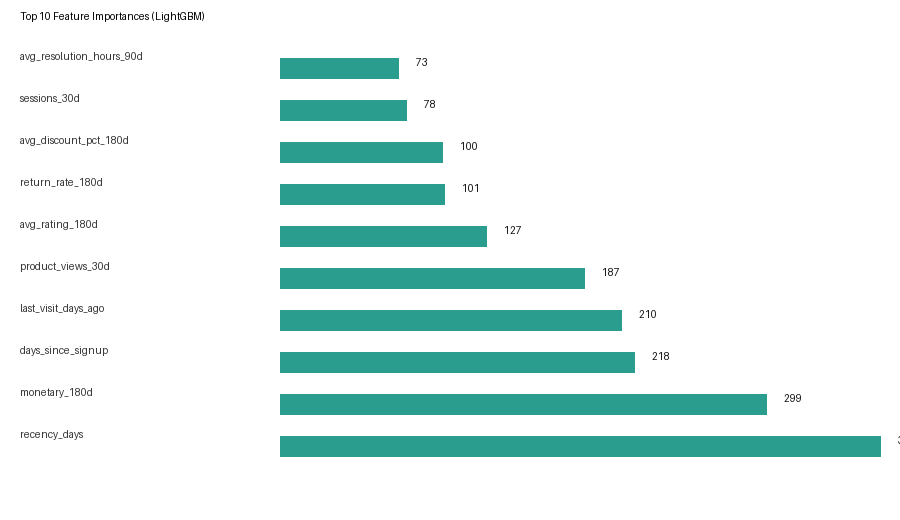

In [8]:
importances = strong_model.feature_importances_
idx = np.argsort(importances)[-10:]
top = pd.Series(importances[idx], index=[feature_names[i] for i in idx]).sort_values()
print(top)

try:
    from IPython.display import Image, display as ipy_display
    ipy_display(Image(filename='charts/feature_importance.png'))
except Exception:
    print('Run train_pipeline.py or re-execute saving cell to generate charts/feature_importance.png')


**Top drivers (business):**
- `recency_days`: Long gaps since last order strongly increase churn risk.
- `monetary_180d`: Lower recent spend often signals disengagement.
- `product_views_30d`: Weak browsing activity complements order-based signals.


## Phase 8 — Save artifacts

In [9]:
# Run full export (creates model.pkl, metrics.json, error_analysis.md, model_card.md)
%run train_pipeline.py


Training complete.
Baseline validation: {'precision': 0.7917, 'recall': 0.7755, 'f1': 0.7835, 'roc_auc': 0.8822, 'pr_auc': 0.8674, 'confusion_matrix': [[159, 30], [33, 114]]}
Strong validation (optimal threshold): {'precision': 0.6087, 'recall': 0.9524, 'f1': 0.7427, 'roc_auc': 0.8752, 'pr_auc': 0.8675, 'confusion_matrix': [[99, 90], [7, 140]]}
Optimal threshold: 0.19999999999999996


## Phase 10 — Validation checklist

In [10]:
from pathlib import Path
import re

checks = []
checks.append(('model.pkl exists', Path('model.pkl').exists()))
metrics = json.loads(Path('metrics.json').read_text())
checks.append(('metrics.json keys', all(k in metrics for k in ['validation', 'optimal_threshold', 'model_type'])))
ea = Path('error_analysis.md').read_text()
ids = re.findall(r'CUST\d{5}', ea)
checks.append(('error_analysis >=10 customer IDs', len(set(ids)) >= 10))
card = Path('model_card.md').read_text()
for section in ['Intended Use', 'Limitations', 'Ethical', 'Monitoring']:
    checks.append((f'model_card has {section}', section.lower() in card.lower()))
checks.append(('no target in X', 'churn_next_60d' not in X.columns and 'split' not in X.columns))

for label, ok in checks:
    print(('✅' if ok else '❌'), label)


✅ model.pkl exists
✅ metrics.json keys
✅ error_analysis >=10 customer IDs
✅ model_card has Intended Use
✅ model_card has Limitations
✅ model_card has Ethical
✅ model_card has Monitoring
✅ no target in X
